In [1]:
import scanpy as sc
import pandas as pd
from pathlib import Path

clean_dir = Path("./Cleaned_MTX_For_Python")
all_batch_results = [] 

# List the batch to skip
SKIP_BATCH = "E19.5 Semi-Allo_Batch 2"

batch_dirs = [d for d in clean_dir.iterdir() if d.is_dir()]

for batch_path in batch_dirs:
    batch_id = batch_path.name 
    if batch_id == SKIP_BATCH:
        print(f">>> Skipping {batch_id} for manual processing.")
        continue
        
    print(f"\n>>> Processing Batch: {batch_id}")
    adata = sc.read_10x_mtx(batch_path, cache=False)
    
    doublet_rate = (adata.n_obs / 1000) * 0.008
    sc.pp.scrublet(adata, expected_doublet_rate=doublet_rate)
    
    # Save results
    res = adata.obs[['doublet_score', 'predicted_doublet']].copy()
    res.rename(columns={'doublet_score': 'Doublet_Score', 'predicted_doublet': 'Doublet_Status'}, inplace=True)
    res['Doublet_Status'] = res['Doublet_Status'].map({True: 'Doublet', False: 'Singlet'})
    
    all_batch_results.append(res)

print(f"\nFinished {len(all_batch_results)} batches.")

>>> Skipping E19.5 Semi-Allo_Batch 2 for manual processing.

>>> Processing Batch: E12.5 Syn_Batch 1

>>> Processing Batch: E19.5 Syn_Batch 2

>>> Processing Batch: E19.5 Semi-Allo_Batch 1

>>> Processing Batch: E12.5 Semi-Allo_Batch 1

Finished 4 batches.


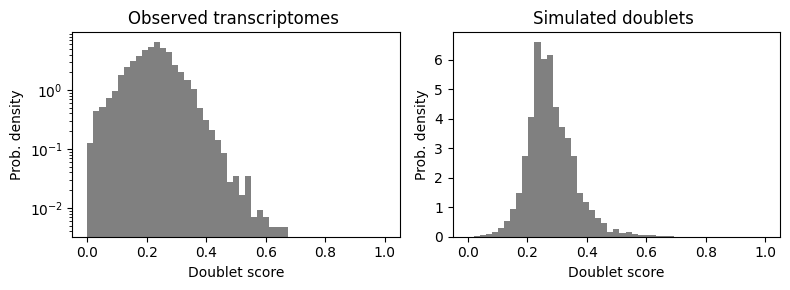

Check the plot for E19.5 Semi-Allo_Batch 2 and decide your threshold!


In [2]:
problematic_id = "E19.5 Semi-Allo_Batch 2"
problematic_path = clean_dir / problematic_id
adata_problematic = sc.read_10x_mtx(problematic_path, cache=False)

doublet_rate = (adata_problematic.n_obs / 1000) * 0.008
sc.pp.scrublet(adata_problematic, expected_doublet_rate=doublet_rate)

sc.pl.scrublet_score_distribution(adata_problematic, save=f"_{problematic_id.replace(' ', '_')}.png")

print(f"Check the plot for {problematic_id} and decide your threshold!")

In [3]:
TH = 0.18 

adata_problematic.obs['predicted_doublet'] = adata_problematic.obs['doublet_score'] > TH

res_problematic = adata_problematic.obs[['doublet_score', 'predicted_doublet']].copy()
res_problematic.rename(columns={'doublet_score': 'Doublet_Score', 'predicted_doublet': 'Doublet_Status'}, inplace=True)
res_problematic['Doublet_Status'] = res_problematic['Doublet_Status'].map({True: 'Doublet', False: 'Singlet'})

all_batch_results.append(res_problematic)

In [4]:
final_df = pd.concat(all_batch_results)
final_df.to_csv("Python_Scrublet_Results.csv", index_label="Barcode")

print(f"Combined {len(all_batch_results)} batches into 'Python_Scrublet_Results.csv'")
print(final_df['Doublet_Status'].value_counts())

Combined 5 batches into 'Python_Scrublet_Results.csv'
Doublet_Status
Singlet    50755
Doublet    40971
Name: count, dtype: int64
